**8/1/25**

The purpose of this notebook is to determine which taxa are responsible for most of the mucin-degrading GH genes we observe in our metagenomics data.

In [1]:
from elliot_utils import *
from glob import glob
from scipy import stats
import colorcet as cc

In [108]:
# Swaps the items in index1 and index2 of inputList
def swapIndices(inputList, index1, index2):
    temp = inputList[index2]
    inputList[index2] = inputList[index1]
    inputList[index1] = temp

# Searches through the annotation for families in 'listOfFamilies', returns the family or -1 if none is found
# Note: Will only work if the family is not annotated with a subfamily, i.e. GH13_32
def getGHFamily(annotation, listOfFamilies):
    for f in listOfFamilies:
        if annotation.find(f + '(') != -1:
            return f
    return -1

# Returns the RPKM for the given gene
# geneReads: How many reads were assigned to the specified gene
# bacterialReads: Total number of bacterial genes in the sample
# proteinObject: Object representing this gene's protein product
def calculateRPKM(geneReads, bacterialReads, proteinObject):
    perMillion = bacterialReads / 1e6
    kilobases = ((len(proteinObject.sequence) * 3) + 3) / 1000
    return (geneReads / perMillion) / kilobases

In [3]:
analysisPath = Path.cwd().joinpath('analysis_files/metagenomic_ghs_pub/')
figPath = Path.cwd().joinpath('figures/metagenomic_ghs_pub/')
ghsRef = ProtRef(analysisPath.joinpath('deduplicated_vaginal_ghs.fasta'))
prot2gh = {} #key=protein ID, value=GH family
allGHObjects = list(ghsRef.db.values())
annotationsDF = pd.read_csv(analysisPath.joinpath('all_ghs_annotations.csv'))
for i in range(len(annotationsDF['ID'])):
    prot2gh[annotationsDF['ID'][i]] = annotationsDF['GH Family'][i]
families = ['GH2', 'GH20', 'GH29', 'GH33', 'GH35', 'GH84', 'GH85', 'GH95', 'GH101']
cutoff = 0.8

In [188]:
largePalette = sns.color_palette(cc.glasbey, n_colors=29)
largePalette.append('gray')
swapIndices(largePalette, 7, 16)
swapIndices(largePalette, 7, 13)
swapIndices(largePalette, 17, 25)
swapIndices(largePalette, 14, 15)
swapIndices(largePalette, 15, 18)
swapIndices(largePalette, 6, 21)
smallPalette = [largePalette[x] for x in [0, 3, 4, 5, 6, 7, 8, 14, 15, 17, 25, 27, 29]]

In [86]:
### Analyze GHs in the full sample set ###
geneMapFile = analysisPath.joinpath('centroids.membership.csv') # This file has the mapping for each gene to its 90% identical representative used in downstream analysis.
geneMap = {} #key=constituent gene, value=representative gene id
with open(geneMapFile, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    skipFirst = True
    for row in reader:
        if skipFirst:
            skipFirst = False
            continue
        geneMap[row[1]] = row[0]
sampleMetadataFile = analysisPath.joinpath('sample_metadata.csv') # This file has sample IDs and Nugent scores for all the samples with metagenomic data
sample2bv = {} #key=sample ID, value='Negative', 'Intermediate', or 'Positive' as determined by BV status
sample2reads = {} #key=sample ID, value=Number of bacterial reads for that sample
with open(sampleMetadataFile, mode='r', newline='') as infile:
    reader = csv.reader(infile)
    skipFirst = True
    for row in reader:
        if skipFirst:
            skipFirst = False
            continue
        nugent = int(row[1])
        if nugent < 4:
            sample2bv[row[0]] = 'Negative'
        elif nugent < 7:
            sample2bv[row[0]] = 'Intermediate'
        else:
            sample2bv[row[0]] = 'Positive'
        sample2reads[row[0]] = int(row[2])
readDataFile = analysisPath.joinpath('read_alignments.csv') # This file has the coverage and number of reads for each gene in the samples

In [87]:
# Object that stores all taxa, GHs, and constituent genes associated with a given representative gene
class RepresentativeGene:
    def __init__(self, identifier):
        self.id = identifier
        self.taxa = set()
        self.groups = set()
        self.group = ''
        self.ghs = set()
        self.constituents = set()

# An unfortunately necessary function to find the index of prot in protList
def getProtIndexFromList(prot, protList):
    for i in range(len(protList)):
        if protList[i].id == prot:
            return i
    return -1

In [96]:
taxon2group = {
    'Actinomyces':'Actinomyces',
    'Amygdalobacter nucleatus':'Amygdalobacter',
    'Anaerococcus':'Anaerococcus',
    'Anaerococcus vaginalis':'Anaerococcus',
    'Anaerococcus vaginalis ATCC 51170':'Anaerococcus',
    'Arcanobacterium haemolyticum':'Arcanobacterium',
    'Arcanobacterium haemolyticum DSM 20595':'Arcanobacterium',
    'Arcanobacterium':'Arcanobacterium',
    'Atopobium':'Atopobium',
    'Bacteroides':'Bacteroides',
    'Bacteroides stercoris':'Bacteroides',
    'Bifidobacterium bifidum':'Bifidobacterium',
    'Bifidobacterium':'Bifidobacterium',
    'Gardnerella sp. KA00735':'Gardnerella',
    'Gardnerella':'Gardnerella',
    'Gardnerella vaginalis':'Gardnerella',
    'Gardnerella piotii':'Gardnerella',
    'Gardnerella pickettii':'Gardnerella',
    'Gardnerella pickettii JCP8017A':'Gardnerella',
    'Gardnerella genomospecies11':'Gardnerella',
    'Gardnerella genomospecies12':'Gardnerella',
    'Hoylesella timonensis':'Hoylesella',
    'Hoylesella timonensis CRIS 5C-B1':'Hoylesella',
    'Prevotella timonensis':'Hoylesella',
    'Hoylesella':'Hoylesella',
    'Hoylesella timonensis S9-PR14':'Hoylesella',
    'Lawsonella clevelandensis':'Lawsonella',
    'Prevotella':'Prevotella',
    'unclassified Prevotella':'Prevotella',
    'Prevotella amnii':'Prevotella',
    'Prevotella amnii DNF00058':'Prevotella',
    'Prevotella amnii CRIS 21A-A':'Prevotella',
    'Prevotella bivia DNF00320':'Prevotella',
    'Prevotella bivia DNF00188':'Prevotella',
    'Prevotella bivia DNF00650':'Prevotella',
    'Prevotella bivia DSM 20514':'Prevotella',
    'Prevotella bivia':'Prevotella',
    'Prevotella buccalis':'Prevotella',
    'Prevotella colorans':'Prevotella',
    'Prevotella bergensis':'Prevotella',
    'Streptococcus':'Streptococcus',
    'Unknown':'Unknown',
    'Bacteroidales':'Unknown',
    'Bifidobacteriaceae':'Unknown',
    'Bacteroidaceae':'Unknown',
    'Bacteria':'Unknown',
    'Actinomycetaceae':'Unknown'
}
allGroups = set()
for v in taxon2group.values():
    allGroups.add(v)
allGroups = list(allGroups)
allGroups.sort()

In [103]:
# This dictionary will be my primary gene reference. It will hold all the RepresentativeGene objects so I can quickly access taxa and GH information for that gene
# If a gene maps to Prevotella and Hoylesella, assign it to Prevotella
representatives = {} #key=representative ID, value=RepresentativeGene object
for constituent, representative in geneMap.items():
    if not representative in representatives.keys():
        representatives[representative] = RepresentativeGene(representative)
    representatives[representative].ghs.add(prot2gh[representative])
    representatives[representative].constituents.add(constituent)
    for t in ghsRef.getProt(constituent).taxa:
        representatives[representative].taxa.add(t)
        representatives[representative].groups.add(taxon2group[t])
for representative in representatives.values():
    if len(representative.groups) == 1:
        representative.group = representative.groups.pop()
    elif 'Prevotella' in representative.groups and 'Hoylesella' in representative.groups:
        representative.group = 'Prevotella'
    elif 'Hoylesella' in representative.groups and 'Unknown' in representative.groups:
        representative.group = 'Hoylesella'
    elif 'Gardnerella' in representative.groups and 'Unknown' in representative.groups:
        representative.group = 'Gardnerella'
    else:
        print('An error occurred')

For all my gene abundance anlysis here, I'm going to use Reads per Kilobase Million (RPKM).

In [114]:
# For each sample type, what is the total RPKM of different GH families?
# Note: For these analyses, I'm going to use a coverage cutoff of >0.8 as my quality filtering
family0 = []
abundance0 = []
bv0 = []
negativeAbundances = [[] for x in range(len(families))] # I will use these arrays to capture the data for statistical testing
intermediateAbundances = [[] for x in range(len(families))]
positiveAbundances = [[] for x in range(len(families))]
readData = pd.read_csv(readDataFile)
familyCounts = [0 for x in families]
currentSample = readData['sample_id'][0]
perMillion = readData['bacterial_reads'][0] / 1e6
count = 0
for i in range(len(readData['std'])):
    perMillion = readData['bacterial_reads'][0] / 1e6
    currentSample = readData['sample_id'][i]
    if float(readData['coverage'][i]) > cutoff:
        family = prot2gh[readData['id'][i]]
        familyCounts[families.index(family)] += calculateRPKM(readData['nreads'][i], readData['bacterial_reads'][i], ghsRef.getProt(readData['id'][i]))
    if i == len(readData['std']) - 1 or currentSample != readData['sample_id'][i + 1]:
        for j in range(len(families)):
            if sample2bv[currentSample] == 'Negative':
                negativeAbundances[j].append(familyCounts[j])
            elif sample2bv[currentSample] == 'Intermediate':
                intermediateAbundances[j].append(familyCounts[j])
            else:
                positiveAbundances[j].append(familyCounts[j])
            if familyCounts[j] > 0:
                family0.append(families[j])
                abundance0.append(familyCounts[j])
                bv0.append(sample2bv[currentSample])
        familyCounts = [0 for x in families]

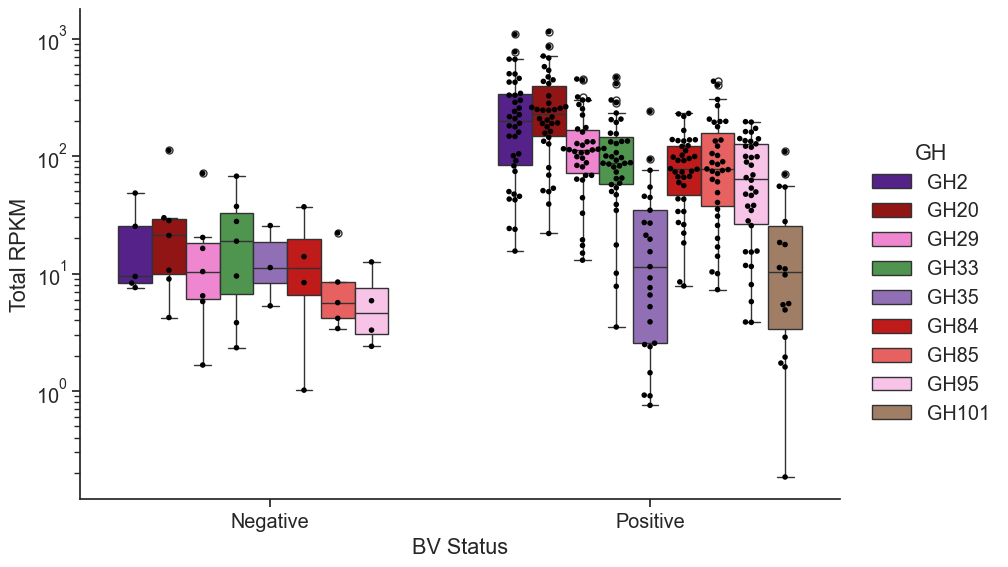

In [235]:
# Graph the gene abundances with 0's removed and exclude the Intermediate samples because I detected GHs in so few of them
dataDF = pd.DataFrame({'GH':family0, 'Total RPKM':abundance0, 'BV Status':bv0})
ghColors = ['#54119a', '#a70000', '#FF76D7', '#44A043', '#9163C1', '#da0000', '#ff4a4a', '#ffbceb', '#A87D5C']
plot = sns.catplot(data=dataDF, x='BV Status', y='Total RPKM', hue='GH', palette=ghColors, aspect=1.5, height=6, kind='box', order=['Negative', 'Positive'])
plot.map(sns.swarmplot, data=dataDF, x='BV Status', y='Total RPKM', order=['Negative', 'Positive'], dodge=True, s=4, hue='GH', hue_order=families, palette=['black' for x in range(9)])
plot.set(yscale='log', ylabel='Total RPKM')
plot.savefig(figPath.joinpath('gh_rpkm.png'), bbox_inches='tight', dpi=300)

In [116]:
# What GH families are significantly more abundant by BV Status?
with open(analysisPath.joinpath('gh_abundance_comparisons_positive-negative.csv'), mode='w', newline='') as outfile:
    writer = csv.writer(outfile)
    writer.writerow(families)
    towrite = []
    x = negativeAbundances
    y = positiveAbundances
    for i in range(len(x)):
        towrite.append(stats.ttest_ind(x[i], y[i]).pvalue)
    writer.writerow(towrite)
with open(analysisPath.joinpath('gh_abundance_comparisons_positive-intermediate.csv'), mode='w', newline='') as outfile:
    writer = csv.writer(outfile)
    writer.writerow(families)
    towrite = []
    x = intermediateAbundances
    y = positiveAbundances
    for i in range(len(x)):
        towrite.append(stats.ttest_ind(x[i], y[i]).pvalue)
    writer.writerow(towrite)
with open(analysisPath.joinpath('gh_abundance_comparisons_negative-intermediate.csv'), mode='w', newline='') as outfile:
    writer = csv.writer(outfile)
    writer.writerow(families)
    towrite = []
    x = negativeAbundances
    y = intermediateAbundances
    for i in range(len(x)):
        towrite.append(stats.ttest_ind(x[i], y[i]).pvalue)
    writer.writerow(towrite)

In [55]:
# I'd like a table readout of:
# -How many samples of each type did we analyze here?
# -How many samples of each type had any GHs at all?
# -How many samples of each type had each of the different GH families detected in them?
header = ['BV Status', 'Total Samples', 'GH+ Samples (%)', 'GH2 (%)', 'GH20 (%)', 'GH29 (%)', 'GH33 (%)', 'GH35 (%)', 'GH84 (%)', 'GH85 (%)', 'GH95 (%)', 'GH101 (%)']
holder = [['Negative', len(negativeAbundances[0])], ['Intermediate', len(intermediateAbundances[0])], ['Positive', len(positiveAbundances[0])]]

# Takes in the sample type abundances. Returns a list formatted in ['GH+ Samples (%)', 'GH2 (%)', 'GH20 (%)', 'GH29 (%)', 'GH33 (%)', 'GH35 (%)', 'GH84 (%)', 'GH85 (%)', 'GH95 (%)', 'GH101 (%)']
def getPrevalence(sampleTypeAbundances):
    numPositive = 0
    familyPresence = [0 for x in range(len(families))]
    for i in range(len(sampleTypeAbundances[0])):
        hasGH = False
        for j in range(len(families)):
            if sampleTypeAbundances[j][i] > 0:
                hasGH = True
                familyPresence[j] += 1
        if hasGH:
            numPositive += 1
    toReturn = [f'{numPositive} ({round((numPositive / len(sampleTypeAbundances[0])) * 100, 1)}%)']
    for i in range(len(familyPresence)):
        toReturn.append(f'{familyPresence[i]} ({round((familyPresence[i] / len(sampleTypeAbundances[0])) * 100, 1)}%)')
    return(toReturn)

for x in getPrevalence(negativeAbundances):
    holder[0].append(x)
for x in getPrevalence(intermediateAbundances):
    holder[1].append(x)
for x in getPrevalence(positiveAbundances):
    holder[2].append(x)

In [189]:
with open(analysisPath.joinpath('prevalence_summary.csv'), mode='w', newline='') as outfile:
    writer = csv.writer(outfile)
    writer.writerow(header)
    for x in holder:
        writer.writerow(x)

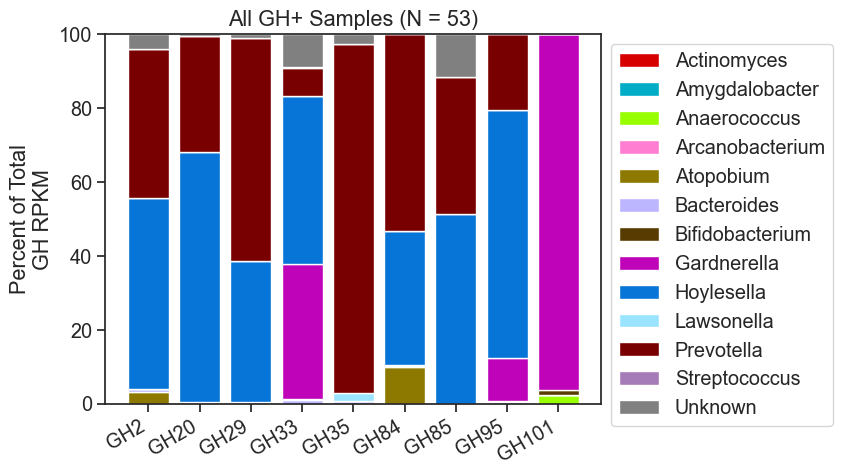

In [238]:
# Across all samples, what is the taxonomic breakdown for the different GHs?
sampleData = []
order = families
specimens = set()
for x in order:
    sampleData.append([0 for x in allGroups])
for i in range(len(readData['std'])):
    perMillion = readData['bacterial_reads'][0] / 1e6
    currentSample = readData['sample_id'][i]
    if float(readData['coverage'][i]) > cutoff:
        family = prot2gh[readData['id'][i]]
        group = representatives[readData['id'][i]].group
        rpkm = calculateRPKM(readData['nreads'][i], readData['bacterial_reads'][i], ghsRef.getProt(readData['id'][i]))
        sampleData[order.index(family)][allGroups.index(group)] += rpkm
groupColors = sns.color_palette(cc.glasbey, n_colors=len(allGroups) - 1)
groupColors.append('gray')
generateNormalizedStackedBar(order, allGroups, sampleData, smallPalette, ylabel='Percent of Total\nGH RPKM', title=f'All GH+ Samples (N = 53)', savepath=None)
plt.xticks(ticks=range(len(families)), labels=families, rotation=30, ha='right');
#plt.legend('',frameon=False);
plt.savefig(figPath.joinpath('big_allsamples_ghs_by_taxa.png'), bbox_inches='tight', dpi=300)

In [191]:
# What percent of GH101 belongs to Gardnerella?
sampleData[8][7] / sum(sampleData[8]) * 100

96.26042741212964

In [192]:
# Across all GH+ samples, what is the taxonomic breakdown of the detected GHs?
reportOrder = ['Negative', 'Intermediate', 'Positive']
tempHolder = [[],[],[]]
readData = pd.read_csv(readDataFile)
groupCounts = [0 for x in allGroups]
for i in range(len(readData['std'])):
    currentSample = readData['sample_id'][i]
    if float(readData['coverage'][i]) > cutoff:
        group = representatives[readData['id'][i]].group
        groupCounts[allGroups.index(group)] += calculateRPKM(readData['nreads'][i], readData['bacterial_reads'][i], ghsRef.getProt(readData['id'][i]))
    if i == len(readData['std']) - 1 or currentSample != readData['sample_id'][i + 1]:
        if sum(groupCounts) > 0:
            tempHolder[reportOrder.index(sample2bv[currentSample])].append([groupCounts, currentSample])
        groupCounts = [0 for x in allGroups]

# Sort within BV statuses by Gardnerella abundance
for x in tempHolder:
    x.sort(key=lambda a : a[0][allGroups.index('Gardnerella')] / sum(a[0]))
sampleData = []
masterOrder = []
bvStatuses = []
for x in tempHolder:
    for i in range(len(x)):
        sampleData.append(x[i][0])
        masterOrder.append(x[i][1])
        if x[i][1].find('neg') != -1:
            bvStatuses.append('-')
        elif x[i][1].find('int') != -1:
            bvStatuses.append('~')
        else:
            bvStatuses.append('+')

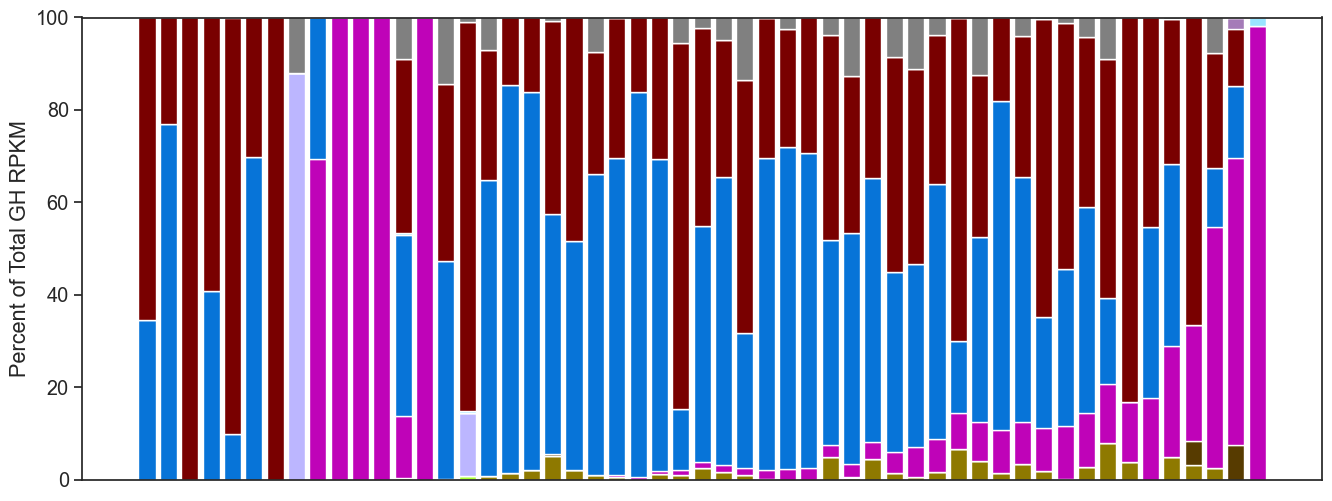

In [194]:
plt.figure(figsize=(16, 6))
generateNormalizedStackedBar(bvStatuses, allGroups, sampleData, smallPalette, ylabel='Percent of Total GH RPKM', savepath=None)
plt.xticks([], rotation=50, ha='right');
plt.legend('',frameon=False);
plt.savefig(figPath.joinpath('big_taxa_all_samples.png'), bbox_inches='tight', dpi=300)

In [195]:
# In how many samples were Hoylesella and Prevotella responsible for more than 50% of GHs?
total = 0
prev = 0
for x in sampleData:
    total += 1
    if (x[8] / sum(x)) + (x[10] / sum(x)) > 0.5:
        prev += 1
print(f'Total samples: {total}. Prevotellaceae dominating GHs: {prev}')

Total samples: 53. Prevotellaceae dominating GHs: 44


In [196]:
# Across all samples, what percent of GHs are attributable to the different groups?
groups = []
percents = []
groupAbund = [0 for x in range(len(allGroups))]
for i in range(len(readData['std'])):
    perMillion = readData['bacterial_reads'][0] / 1e6
    currentSample = readData['sample_id'][i]
    if float(readData['coverage'][i]) > cutoff:
        groupAbund[allGroups.index(representatives[readData['id'][i]].group)] += calculateRPKM(readData['nreads'][i], readData['bacterial_reads'][i], ghsRef.getProt(readData['id'][i]))
    if i == len(readData['std']) - 1 or currentSample != readData['sample_id'][i + 1]:
        if sum(groupAbund) > 0:
            for j in range(len(allGroups)):
                groups.append(allGroups[j])
                percents.append((groupAbund[j] / sum(groupAbund)) * 100)
        groupAbund = [0 for x in range(len(allGroups))]

C:\Users\emlee\AppData\Local\Temp\ipykernel_4584\3228111309.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(data=pd.DataFrame({'Genus':groups, 'Percent of Total\nGH RPKM':percents}), x='Genus', y='Percent of Total\nGH RPKM', palette=smallPalette)
C:\Users\emlee\AppData\Local\Temp\ipykernel_4584\3228111309.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(allGroups, rotation=40, ha='right')


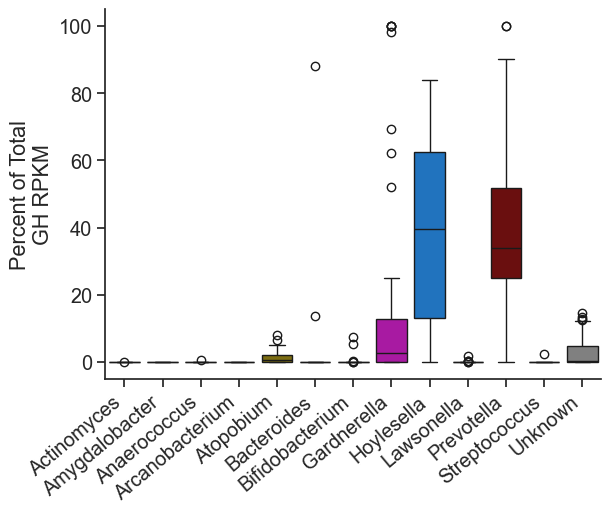

In [237]:
plot = sns.boxplot(data=pd.DataFrame({'Genus':groups, 'Percent of Total\nGH RPKM':percents}), x='Genus', y='Percent of Total\nGH RPKM', palette=smallPalette)
plot.set(xlabel='')
plot.set_xticklabels(allGroups, rotation=40, ha='right')
sns.despine()
saveFig(plot, figPath.joinpath('gh_contribution.png'))

In [156]:
groupHolder = {}
for g in allGroups:
    groupHolder[g] = []
for i in range(len(groups)):
    groupHolder[groups[i]].append(percents[i])

In [157]:
stats.ttest_ind(groupHolder['Hoylesella'], groupHolder['Gardnerella'])

TtestResult(statistic=3.7804181270208197, pvalue=0.000261518958199253, df=104.0)

In [158]:
stats.ttest_ind(groupHolder['Hoylesella'], groupHolder['Prevotella'])

TtestResult(statistic=-0.04265024689105097, pvalue=0.966062118090514, df=104.0)

In [159]:
stats.ttest_ind(groupHolder['Prevotella'], groupHolder['Gardnerella'])

TtestResult(statistic=3.8802522492625333, pvalue=0.00018332145139636402, df=104.0)

In [160]:
stats.kruskal(groupHolder['Actinomyces'], groupHolder['Amygdalobacter'], groupHolder['Anaerococcus'], groupHolder['Arcanobacterium'], groupHolder['Atopobium'], groupHolder['Bacteroides'], groupHolder['Bifidobacterium'], groupHolder['Gardnerella'], groupHolder['Hoylesella'], groupHolder['Lawsonella'], groupHolder['Prevotella'], groupHolder['Streptococcus'])

KruskalResult(statistic=396.5822148708493, pvalue=3.2523100010392506e-78)

In [161]:
print(stats.tukey_hsd(groupHolder['Actinomyces'], groupHolder['Amygdalobacter'], groupHolder['Anaerococcus'], groupHolder['Arcanobacterium'], groupHolder['Atopobium'], groupHolder['Bacteroides'], groupHolder['Bifidobacterium'], groupHolder['Gardnerella'], groupHolder['Hoylesella'], groupHolder['Lawsonella'], groupHolder['Prevotella'], groupHolder['Streptococcus']))

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.002     1.000    -9.179     9.182
 (0 - 2)     -0.011     1.000    -9.192     9.169
 (0 - 3)      0.002     1.000    -9.179     9.182
 (0 - 4)     -1.431     1.000   -10.611     7.750
 (0 - 5)     -1.916     1.000   -11.096     7.265
 (0 - 6)     -0.248     1.000    -9.429     8.932
 (0 - 7)    -16.898     0.000   -26.078    -7.717
 (0 - 8)    -38.071     0.000   -47.251   -28.890
 (0 - 9)     -0.052     1.000    -9.232     9.129
 (0 - 10)    -38.290     0.000   -47.470   -29.110
 (0 - 11)     -0.044     1.000    -9.224     9.137
 (1 - 0)     -0.002     1.000    -9.182     9.179
 (1 - 2)     -0.013     1.000    -9.194     9.167
 (1 - 3)      0.000     1.000    -9.180     9.180
 (1 - 4)     -1.432     1.000   -10.613     7.748
 (1 - 5)     -1.917     1.000   -11.098     7.263
 (1 - 6)     -0.250     1.000    -9.430     8.931
 (1 - 7)    -16.899     0.000 

In [198]:
### Look at the overall taxonomic makeup of all these samples using Metaphlan analysis of the metagenomics data
metaphlanFiles = getOrderedFiles(analysisPath.joinpath('metagenomics_metaphlan/'), '.metaphlan')

In [199]:
# Do an initial pass to get all the genera that were present at >0.5% relative abundance in at least one sample
metagenomicGenera = set()
for i in range(len(metaphlanFiles)):
    with metaphlanFiles[i].open(mode='r') as infile:
        reader = csv.reader(infile, delimiter='\t')
        for row in reader:
            if 'k__Bacteria' in row[0]:
                clades = row[0].split('|')
                lastClades = clades[len(clades) - 1]
                if 'g__' in lastClades and float(row[2]) > 0.5:
                    metagenomicGenera.add(lastClades[3:])
metagenomicGenera = list(metagenomicGenera)
metagenomicGenera.sort()
print(metagenomicGenera)

['Aerococcus', 'Alloscardovia', 'Anaerococcus', 'Arcanobacterium', 'Bacteroidales_unclassified', 'Bifidobacteriaceae_unclassified', 'Bifidobacterium', 'Coriobacteriales_unclassified', 'Corynebacterium', 'Dialister', 'Eubacteriales_unclassified', 'Fannyhessea', 'Fenollaria', 'GGB1460', 'GGB3012', 'GGB4277', 'GGB4807', 'GGB73389', 'GGB753', 'GGB754', 'Gardnerella', 'Lachnospiraceae_unclassified', 'Lactobacillus', 'Lawsonella', 'Limosilactobacillus', 'Mageeibacillus', 'Megasphaera', 'Metamycoplasma', 'Mobiluncus', 'Peptoniphilus', 'Peptostreptococcus', 'Porphyromonas', 'Prevotella', 'Sneathia', 'Streptococcus', 'Tissierellia_unclassified', 'Veillonella', 'Veillonellaceae_unclassified']


In [200]:
# Make a reference to handle ambiguous classifications which I'm simply going to bin into unknown
metaphlan2group = { #key=metaphlan taxonomic assignment, value=group that will be reported
    'Bacteroidales_unclassified':'Unknown',
    'Bifidobacteriaceae_unclassified':'Unknown',
    'Coriobacteriales_unclassified':'Eggerthella sp.',
    'Eubacteriales_unclassified':'Unknown',
    'GGB1460':'Unknown',
    'GGB3012':'Unknown',
    'GGB4277':'Unknown',
    'GGB4807':'Unknown',
    'GGB73389':'Unknown',
    'GGB753':'Unknown',
    'GGB754':'Unknown',
    'Lachnospiraceae_unclassified':'Unknown',
    'Limosilactobacillus':'Lactobacillus',
    'Tissierellia_unclassified':'Unknown',
    'Veillonellaceae_unclassified':'Unknown'
}
metagenomicGenera = set()
for i in range(len(metaphlanFiles)):
    with metaphlanFiles[i].open(mode='r') as infile:
        reader = csv.reader(infile, delimiter='\t')
        for row in reader:
            if 'k__Bacteria' in row[0]:
                clades = row[0].split('|')
                lastClades = clades[len(clades) - 1]
                if 'g__' in lastClades and float(row[2]) > 0.5:
                    genus = lastClades[3:]
                    if not genus in metaphlan2group.keys():
                        metaphlan2group[genus] = genus
                    metagenomicGenera.add(metaphlan2group[genus])
metagenomicGenera = list(metagenomicGenera)
metagenomicGenera.append('Actinomyces')
metagenomicGenera.append('Amygdalobacter')
metagenomicGenera.append('Atopobium')
metagenomicGenera.append('Bacteroides')
metagenomicGenera.append('Hoylesella')
metagenomicGenera.sort()
metagenomicGenera.remove('Unknown')
metagenomicGenera.append('Unknown')
print(metagenomicGenera)

['Actinomyces', 'Aerococcus', 'Alloscardovia', 'Amygdalobacter', 'Anaerococcus', 'Arcanobacterium', 'Atopobium', 'Bacteroides', 'Bifidobacterium', 'Corynebacterium', 'Dialister', 'Eggerthella sp.', 'Fannyhessea', 'Fenollaria', 'Gardnerella', 'Hoylesella', 'Lactobacillus', 'Lawsonella', 'Mageeibacillus', 'Megasphaera', 'Metamycoplasma', 'Mobiluncus', 'Peptoniphilus', 'Peptostreptococcus', 'Porphyromonas', 'Prevotella', 'Sneathia', 'Streptococcus', 'Veillonella', 'Unknown']


In [201]:
metagenomicAbundancesTemp = {} #key=sampleName, value=list of genus abundances
# Pull the genus abundance data in from the metaphlan files
for i in range(len(metaphlanFiles)):
    totalReads = 0
    counts = [0 for x in range(len(metagenomicGenera))]
    with metaphlanFiles[i].open(mode='r') as infile:
        reader = csv.reader(infile, delimiter='\t')
        for row in reader:
            if 'k__Bacteria' in row[0]:
                clades = row[0].split('|')
                lastClades = clades[len(clades) - 1]
                readCount = 0
                if 'g__' in lastClades and float(row[2]) > 0.5 and lastClades.find('Prevotella') == -1: # I'm going to treat Prevotella slightly differently to separate out Prevotella vs Hoylesella, so pass over Prevotella here
                    genus = lastClades[3:]
                    taxon = metaphlan2group[genus]
                    readCount = int(row[4])
                    totalReads += readCount
                    counts[metagenomicGenera.index(taxon)] += readCount
                elif 's__Prevotella' in lastClades and float(row[2]) > 0.5:
                    readCount = int(row[4])
                    totalReads += readCount
                    if 'timonensis' in lastClades:
                        counts[metagenomicGenera.index('Hoylesella')] += readCount
                    else:
                        counts[metagenomicGenera.index('Prevotella')] += readCount
    toAppend = []
    if totalReads > 0:
        for c in counts:
            toAppend.append((c / totalReads) * 100)
        sampleName = metaphlanFiles[i].stem
        metagenomicAbundancesTemp[sampleName] = counts
metagenomicAbundances = []
for x in masterOrder:
    metagenomicAbundances.append(metagenomicAbundancesTemp[x])

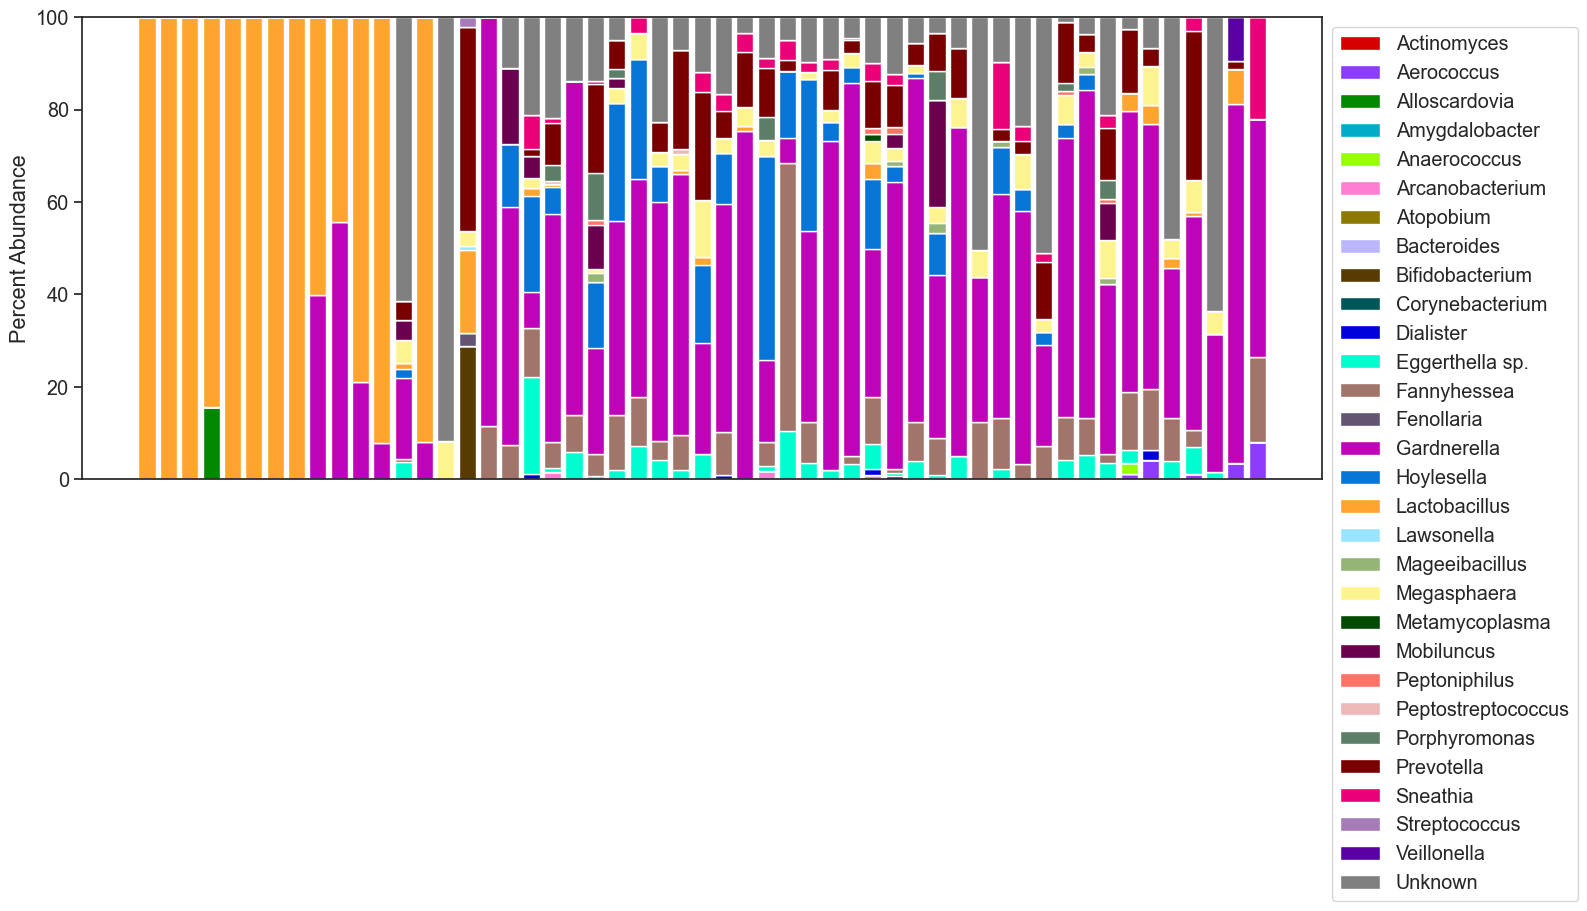

In [234]:
plt.figure(figsize=(16, 6))
generateNormalizedStackedBar(bvStatuses, metagenomicGenera, metagenomicAbundances, largePalette, title='', ylabel='Percent Abundance', xLabTotals=False, sort=False, legendOrder=None)
plt.xticks([], rotation=50, ha='right');
#plt.legend('',frameon=False);
plt.savefig(figPath.joinpath('sample_taxonomy_metagenomics.png'), bbox_inches='tight', dpi=300)

In [205]:
# Across all GH+ samples, what is the GH family breakdown per sample?
familyAbundancesTemp = {} #key=sampleName, value=list of family abundances
readData = pd.read_csv(readDataFile)
familyCounts = [0 for x in families]
for i in range(len(readData['std'])):
    currentSample = readData['sample_id'][i]
    if float(readData['coverage'][i]) > cutoff:
        family = prot2gh[readData['id'][i]]
        familyCounts[families.index(family)] += calculateRPKM(readData['nreads'][i], readData['bacterial_reads'][i], ghsRef.getProt(readData['id'][i]))
    if i == len(readData['std']) - 1 or currentSample != readData['sample_id'][i + 1]:
        if sum(familyCounts) > 0:
            familyAbundancesTemp[currentSample] = familyCounts
        familyCounts = [0 for x in families]
familyAbundances = []
for x in masterOrder:
    familyAbundances.append(familyAbundancesTemp[x])

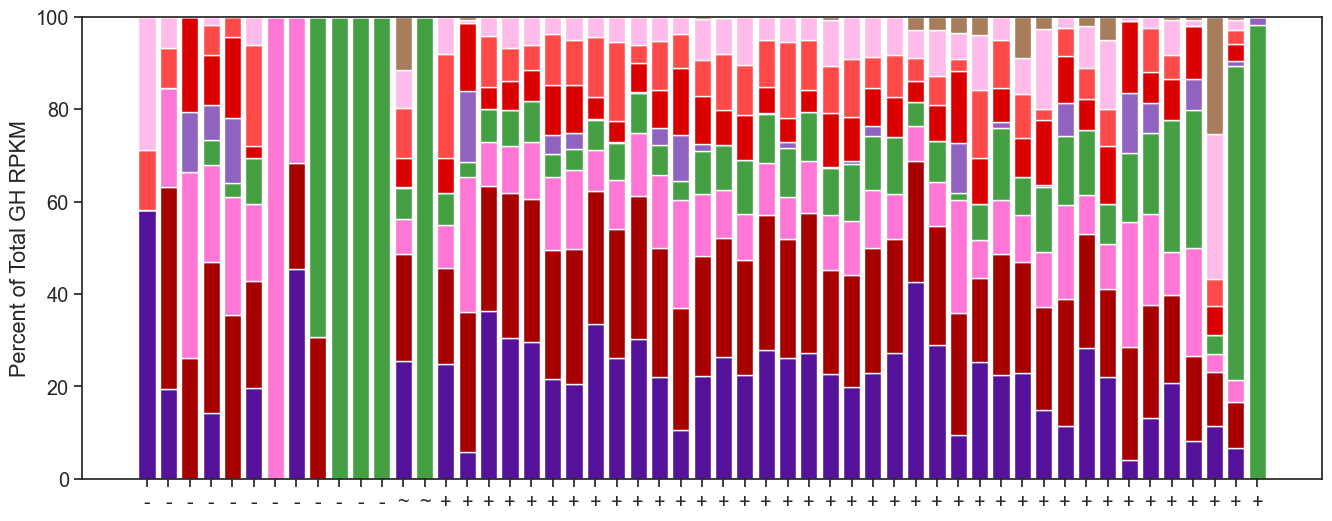

In [233]:
plt.figure(figsize=(16, 6))
generateNormalizedStackedBar(bvStatuses, families, familyAbundances, ghColors, ylabel='Percent of Total GH RPKM', savepath=None)
#plt.xticks([], rotation=50, ha='right');
plt.legend('',frameon=False);
#plt.savefig(figPath.joinpath('big_families_all_samples.png'), bbox_inches='tight', dpi=300)

In [208]:
# Determine how much each group is over- or under-represented in the GH data compared to their
# overall presence in the community (GH Abundance - Overall Abundance)
#metagenomicAbundances: Overall abundance in community
#genusData: Abundance by GHs
differenceData = {'Taxon':[], 'Delta':[]}
for i in range(len(allGroups)):
    groupIndex = metagenomicGenera.index(allGroups[i])
    for j in range(len(metagenomicAbundances)):
        ghAbundance = (sampleData[j][i] / sum(sampleData[j])) * 100
        metaAbundance = (metagenomicAbundances[j][groupIndex] / sum(metagenomicAbundances[j])) * 100
        differenceData['Taxon'].append(allGroups[i])
        differenceData['Delta'].append(ghAbundance - metaAbundance)

C:\Users\emlee\AppData\Local\Temp\ipykernel_4584\695904978.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.catplot(data=pd.DataFrame(differenceData), x='Taxon', y='Delta', aspect=2, kind='box', palette=smallPalette, legend=False)


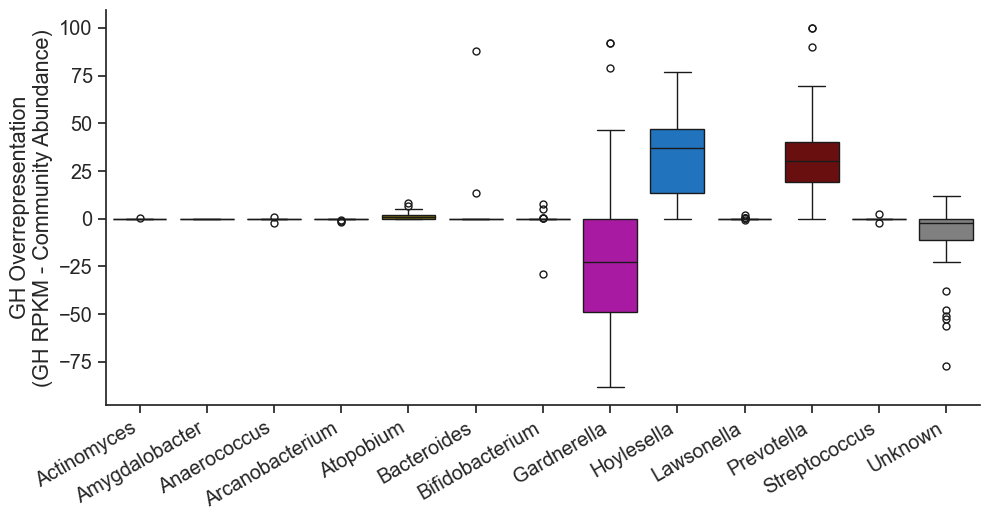

In [239]:
plot = sns.catplot(data=pd.DataFrame(differenceData), x='Taxon', y='Delta', aspect=2, kind='box', palette=smallPalette, legend=False)
plot.set_xticklabels(allGroups, rotation=30, ha='right')
plot.set(xlabel='', ylabel='GH Overrepresentation\n(GH RPKM - Community Abundance)')
plot.savefig(figPath.joinpath('gh_overrepresentation.png'), bbox_inches='tight', dpi=300)

In [210]:
# Is Hoylesella significantly overrepresented in the GHs compared to its community abundance?
stats.ttest_1samp(sliceDFBy(pd.DataFrame(differenceData), ['Taxon'], [['Hoylesella']])['Delta'], 0)

TtestResult(statistic=10.614279914386012, pvalue=1.2741295750188937e-14, df=52)

In [211]:
# Is Prevotella significantly overrepresented in the GHs compared to its community abundance?
stats.ttest_1samp(sliceDFBy(pd.DataFrame(differenceData), ['Taxon'], [['Prevotella']])['Delta'], 0)

TtestResult(statistic=9.985559277884931, pvalue=1.092696944407631e-13, df=52)

In [217]:
# How well does percent abundance of the Hoylesella correlate with overall GH abundance?
correlationDataHoylesella = {'Hoylesella Abundance':[], 'Total GH RPKM':[]}
for i in range(len(metagenomicAbundances)):
    ghAbundance = sum(sampleData[i])
    hAbundance = (metagenomicAbundances[i][metagenomicGenera.index('Hoylesella')] / sum(metagenomicAbundances[i])) * 100
    correlationDataHoylesella['Hoylesella Abundance'].append(hAbundance)
    correlationDataHoylesella['Total GH RPKM'].append(ghAbundance)

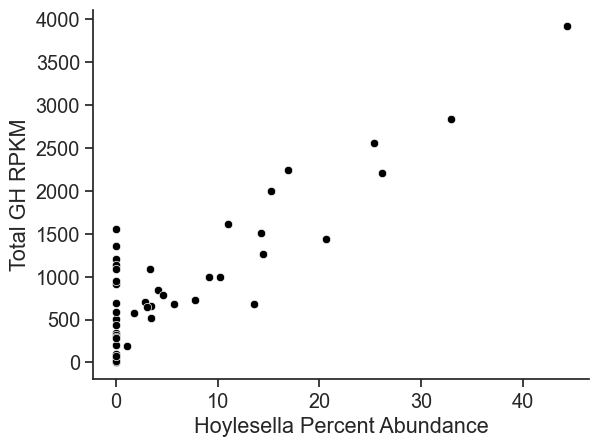

In [218]:
plot = sns.scatterplot(data=pd.DataFrame(correlationDataHoylesella), x='Hoylesella Abundance', y='Total GH RPKM', color='black')
plot.set(xlabel='Hoylesella Percent Abundance')
sns.despine()
saveFig(plot, figPath.joinpath('scatterplot_hoylesella.png'))

In [219]:
print(stats.linregress(correlationDataHoylesella['Hoylesella Abundance'], correlationDataHoylesella['Total GH RPKM']))

LinregressResult(slope=74.89191660591926, intercept=413.2981045468837, rvalue=0.8717913411264344, pvalue=1.9838981087878466e-17, stderr=5.892840704681533, intercept_stderr=64.86673998017001)


In [221]:
# How well does percent abundance of the Prevotella correlate with overall GH abundance?
correlationDataPrevotella = {'Prevotella Abundance':[], 'Total GH RPKM':[]}
for i in range(len(metagenomicAbundances)):
    ghAbundance = sum(sampleData[i])
    pAbundance = (metagenomicAbundances[i][metagenomicGenera.index('Prevotella')] / sum(metagenomicAbundances[i])) * 100
    correlationDataPrevotella['Prevotella Abundance'].append(pAbundance)
    correlationDataPrevotella['Total GH RPKM'].append(ghAbundance)

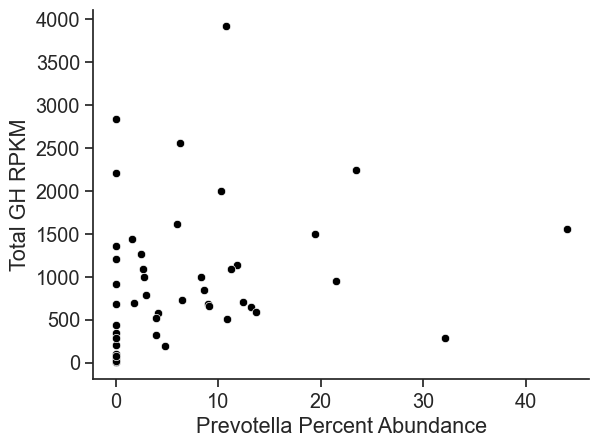

In [222]:
plot = sns.scatterplot(data=pd.DataFrame(correlationDataPrevotella), x='Prevotella Abundance', y='Total GH RPKM', color='black')
plot.set(xlabel='Prevotella Percent Abundance')
sns.despine()
saveFig(plot, figPath.joinpath('scatterplot_prevotella.png'))

In [223]:
print(stats.linregress(correlationDataPrevotella['Prevotella Abundance'], correlationDataPrevotella['Total GH RPKM']))

LinregressResult(slope=27.60414633585733, intercept=665.1519780292978, rvalue=0.29705529841581324, pvalue=0.03076908802386245, stderr=12.42486723709752, intercept_stderr=132.1854698673486)


In [224]:
# How well does percent abundance of Gardnerella correlate with overall GH abundance?
correlationDataGardnerella = {'Gardnerella Abundance':[], 'Total GH RPKM':[]}
for i in range(len(metagenomicAbundances)):
    ghAbundance = sum(sampleData[i])
    gAbundance = (metagenomicAbundances[i][metagenomicGenera.index('Gardnerella')] / sum(metagenomicAbundances[i])) * 100
    correlationDataGardnerella['Gardnerella Abundance'].append(gAbundance)
    correlationDataGardnerella['Total GH RPKM'].append(ghAbundance)

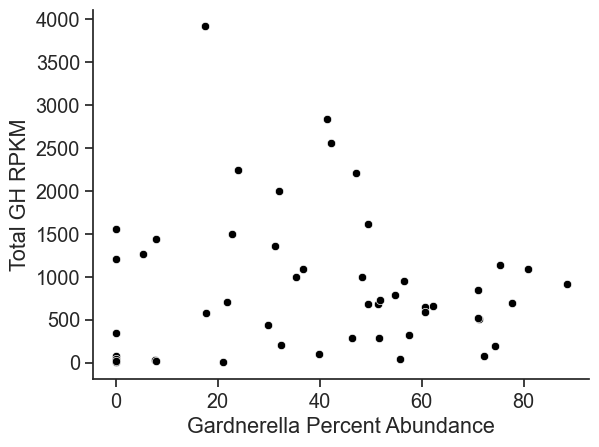

In [225]:
plot = sns.scatterplot(data=pd.DataFrame(correlationDataGardnerella), x='Gardnerella Abundance', y='Total GH RPKM', color='black')
plot.set(xlabel='Gardnerella Percent Abundance')
sns.despine()
saveFig(plot, figPath.joinpath('scatterplot_gardnerella.png'))

In [228]:
print(stats.linregress(correlationDataGardnerella['Gardnerella Abundance'], correlationDataGardnerella['Total GH RPKM']))

LinregressResult(slope=1.6402866229195083, intercept=770.7160149925471, rvalue=0.053422894416294046, pvalue=0.7040032822631117, stderr=4.293254318408467, intercept_stderr=195.44746391225507)
